# What are the most demanded skills for the top 3 most popular data roles?

#### Methodology
1. Clean-up skill column
2. Calculate skill count based on `job_title_short`
3. Calculate skill percentage
4. Plot final findings



In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/home/harsh/Desktop/python/advanced/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Filter Data for the Various Countries 

Filter the data for the market of the Various Countries.

In [2]:
Country='Germany'
df_country=df[df['job_country']==Country]

## Explode Skills

Converts the `job_skills` column from string representations of lists into actual list objects and then expands these lists so each skill appears in its own row. It then displays the `job_title` and `job_skills` columns, allowing us to analyze the distribution of skills across different data job titles.

In [3]:
df_skills=df_country.explode('job_skills')
df_skills[['job_title_short','job_skills']]

,job_title_short,job_skills
2,Data Engineer,python
2,Data Engineer,sql
2,Data Engineer,c#
2,Data Engineer,azure
2,Data Engineer,airflow
...,...,...
785735,Senior Data Engineer,docker
785737,Data Analyst,sas
785737,Data Analyst,sas
785737,Data Analyst,sql


## Count Skills per Job Title

Groups DataFrame by `job_skills` and `job_title_short`, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to 'count'. The final DataFrame, `df_skills_count`, shows the frequency of each skill with each job title.

In [4]:
df_skills_count=df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count=df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count',inplace=True,ascending=False)
df_skills_count

,job_skills,job_title_short,skill_count
907,python,Data Scientist,4157
906,python,Data Engineer,3524
1139,sql,Data Engineer,3145
1138,sql,Data Analyst,2947
905,python,Data Analyst,2309
...,...,...,...
1369,yarn,Data Analyst,1
1371,yarn,Data Scientist,1
1375,zoom,Data Engineer,1
792,outlook,Cloud Engineer,1


## Create List of Top 3 Roles

#### Focus: Data Analysts, Data Engineers, and Data Scientists

Filter the job titles based on the most popular.

we also introduced a new variable max_length to later provide length to the x-axis while formatting our chart (x_lim function) 


In [5]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles=sorted(job_titles[:3])
job_titles
max_length = int(df_skills_count['skill_count'].max() + 500)



## Plot Skill Counts

Creates a stacked horizontal bar chart for the top 5 skills for Top 3 roles, displaying the frequency of each skill. 

if you look closely here we used our max_length variable in x_lim function 

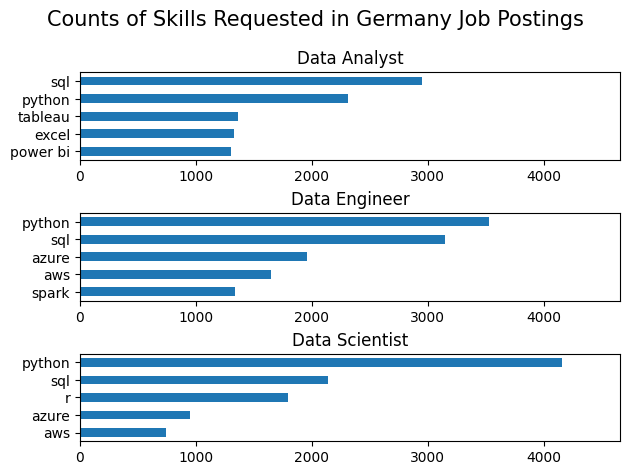

In [6]:
fig, ax=plt.subplots(len(job_titles),1)

for i,job_title in enumerate(job_titles): 
    df_plot=df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title=job_title)
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, max_length) # make the scales the same

fig.suptitle(f'Counts of Skills Requested in {Country} Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap

## Convert Counts to Percentages

#### Focus: Counts don't show what portions of jobs are requesting these skills

So we'll convert the counts into percentages which helps us understand how each job title represents relative to the entire dataset. 

Before we can calculate the percentages we need the total counts for the jobs posted by job title. Calculate the frequency of each job title using the `value_counts()` method on the `job_title_short` column. Then reset the index to transform the Series into a DataFrame and renames the columns to `job_title_short` and `total`. The DataFrame `df_job_title_count` now holds a list of job titles alongside their total occurrences.

In [7]:
df_job_title_count=df_country['job_title_short'].value_counts().reset_index(name='job_total')
df_job_title_count

,job_title_short,job_total
0,Data Analyst,7131
1,Data Scientist,6745
2,Data Engineer,6675
3,Senior Data Engineer,2041
4,Senior Data Scientist,1737
5,Senior Data Analyst,1216
6,Business Analyst,817
7,Software Engineer,741
8,Machine Learning Engineer,402
9,Cloud Engineer,189


Then we calculate the percentages. First merge `df_skills_count` and `df_job_title_count`, based on the 'job_title_short' column, ensuring each skill count is associated with the total number of job postings for that title. Then calculate the percentage of each skill within its job title by dividing the skill count by the total job postings and multiplying by 100, adding this new data as a 'percentage' column. 

In [8]:
df_skill_perc=pd.merge(df_skills_count,df_job_title_count,how='left' ,on='job_title_short')
df_skill_perc['skill_percentage']=100*df_skill_perc['skill_count']/df_skill_perc['job_total']
df_skill_perc

,job_skills,job_title_short,skill_count,job_total,skill_percentage
0,python,Data Scientist,4157,6745,61.630838
1,python,Data Engineer,3524,6675,52.794007
2,sql,Data Engineer,3145,6675,47.116105
3,sql,Data Analyst,2947,7131,41.326602
4,python,Data Analyst,2309,7131,32.379750
...,...,...,...,...,...
1377,yarn,Data Analyst,1,7131,0.014023
1378,yarn,Data Scientist,1,6745,0.014826
1379,zoom,Data Engineer,1,6675,0.014981
1380,outlook,Cloud Engineer,1,189,0.529101


## Plot Percentage Count

Filters and sorts a DataFrame to get the top 5 skills percentages for these top 3 roles. After sorting the skills by descending percentage, reverse the order of these top 5 entries to use in a horizontal bar plot, which by default starts plotting from the bottom.

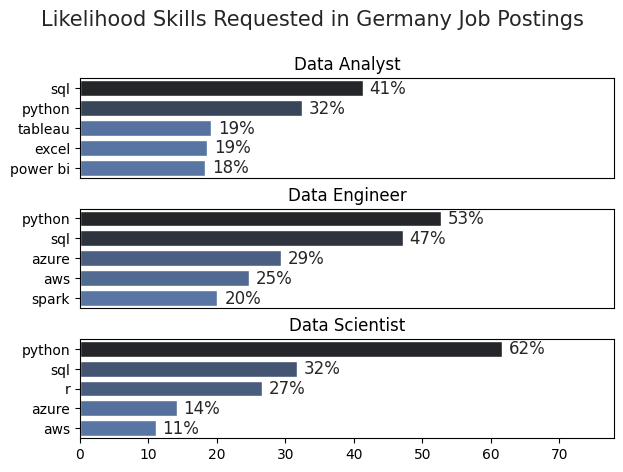

In [9]:
fig, ax=plt.subplots(len(job_titles),1)
sns.set_theme(style='ticks')

for i,job_title in enumerate(job_titles): 
    df_plot=df_skill_perc[df_skill_perc['job_title_short']==job_title].head(5)
    # df_plot.plot(kind='barh',x='job_skills',y='skill_percentage',ax=ax[i],title=job_title)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78) # make the scales the same

    for n,v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v + 1,n,f'{v:.0f}%',va='center')
        # ax[i].text(v + 1, n, f'{v:.0f}%', va='center')
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
fig.suptitle(f'Likelihood Skills Requested in {Country} Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap